# ₿ Bitcoin Time Series Analysis — Complete Notebook
### Advanced Pipeline: EDA → Stationarity → Decomposition → Forecasting → Risk → Monte Carlo
> **Dataset:** BTC-USD Daily OHLCV | Sep 2014 – Dec 2023 | 3,392 observations  
> **Author:** Senior Data Science Analysis  
> **Models:** ARIMA · Holt-Winters · Random Forest · Gradient Boosting · Monte Carlo (GBM)

## 0. Install & Import Libraries

In [1]:
# Install required libraries (run once)
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn scipy xgboost lightgbm pmdarima -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Statsmodels
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print('All libraries imported successfully ✓')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

All libraries imported successfully ✓
Pandas: 3.0.3 | NumPy: 2.4.4


### Global Plot Theme (Dark Bitcoin Style)

In [3]:
# ── Color Palette ──────────────────────────────────────
BG     = '#0d1117'
CARD   = '#161b22'
ACCENT = '#f7931a'  # Bitcoin Orange
BLUE   = '#58a6ff'
GREEN  = '#3fb950'
RED    = '#f85149'
PURPLE = '#bc8cff'
TEAL   = '#39d353'
GRAY   = '#8b949e'
WHITE  = '#e6edf3'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor': CARD,
    'axes.edgecolor':   GRAY, 'axes.labelcolor': WHITE,
    'xtick.color':      GRAY, 'ytick.color': GRAY,
    'text.color':       WHITE,'grid.color': '#21262d',
    'grid.linewidth':   0.5,  'font.family': 'DejaVu Sans',
    'axes.titlesize':   12,   'axes.titleweight': 'bold',
    'figure.dpi':       120,
})
print('Theme applied ✓')

Theme applied ✓


## 1. Data Loading & Preprocessing
### What we do
- Parse dates, sort chronologically, set Date as index
- Engineer derived columns: log price, daily log returns, daily % returns
- Check for missing values and data quality

### Why
Log-returns are used throughout because: (1) they are additive over time, (2) they are approximately normally distributed, and (3) they induce stationarity via first-differencing of log-price.

In [4]:
# ── Load ──────────────────────────────────────────────
df = pd.read_csv('bitcoin_price.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)

# ── Derived columns ────────────────────────────────────
df['log_close']  = np.log(df['Close'])
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['pct_return'] = df['Close'].pct_change() * 100
df['daily_range'] = df['High'] - df['Low']

price    = df['Close']
log_price= df['log_close']
log_ret  = df['log_return'].dropna()
returns  = df['pct_return'].dropna()

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')
print(f'Missing values:\n{df.isnull().sum()}')
print('\nDescriptive Statistics (Close Price):')
df['Close'].describe().apply(lambda x: f'${x:,.2f}')

Shape: (3392, 10)
Date range: 2014-09-17 → 2023-12-30
Missing values:
Open           0
High           0
Low            0
Close          0
Adj Close      0
Volume         0
log_close      0
log_return     1
pct_return     1
daily_range    0
dtype: int64

Descriptive Statistics (Close Price):


count     $3,392.00
mean     $14,574.91
std      $16,184.52
min         $178.10
25%         $915.99
50%       $8,244.67
75%      $23,776.68
max      $67,566.83
Name: Close, dtype: str

## 2. Exploratory Data Analysis (EDA)
### Panel Chart: Price + Returns + Volume
Three-panel chart with annotated macro events. Log-scale on price is critical — a linear scale compresses the 2014–2016 period into a flat line, hiding structure.

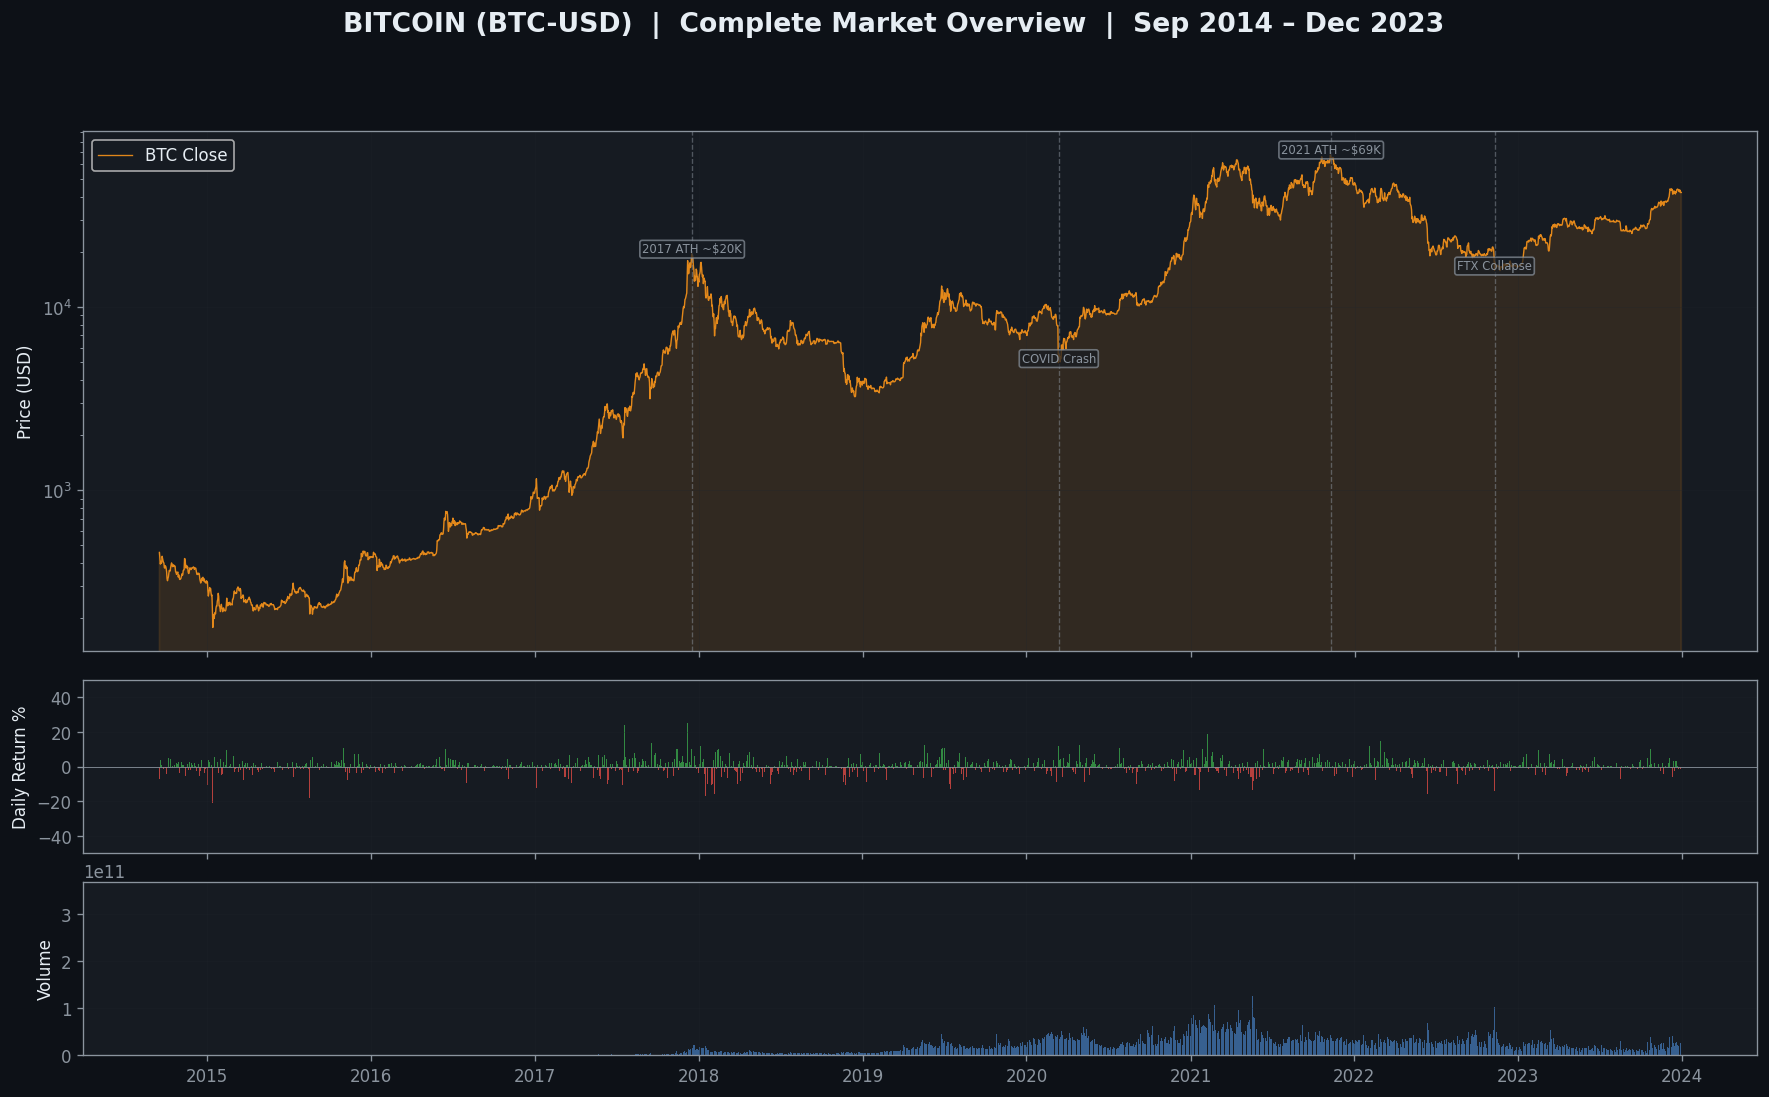

In [5]:
fig = plt.figure(figsize=(18, 10), facecolor=BG)
fig.suptitle('BITCOIN (BTC-USD)  |  Complete Market Overview  |  Sep 2014 – Dec 2023',
             fontsize=16, fontweight='bold', color=WHITE, y=0.98)

gs = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[3, 1, 1], hspace=0.1)

# ── Price (log scale) ──────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(price.index, price.values, color=ACCENT, linewidth=0.8, alpha=0.9, label='BTC Close')
ax1.fill_between(price.index, price.values, alpha=0.12, color=ACCENT)

events = {
    '2017-12-17': ('2017 ATH ~$20K', 19783),
    '2020-03-13': ('COVID Crash',     5000),
    '2021-11-10': ('2021 ATH ~$69K', 68789),
    '2022-11-09': ('FTX Collapse',   16000),
}
for date_str, (label, y_val) in events.items():
    ax1.axvline(pd.to_datetime(date_str), color=GRAY, linestyle='--', alpha=0.5, linewidth=0.8)
    ax1.annotate(label, xy=(pd.to_datetime(date_str), y_val), fontsize=7, color=GRAY,
                 ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor=CARD, edgecolor=GRAY, alpha=0.7))

ax1.set_ylabel('Price (USD)'); ax1.set_yscale('log')
ax1.grid(True, alpha=0.3); ax1.legend(loc='upper left'); ax1.set_xticklabels([])

# ── Daily Returns ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
colors_ret = [GREEN if r > 0 else RED for r in returns]
ax2.bar(returns.index, returns.values, color=colors_ret, alpha=0.7, width=0.8)
ax2.axhline(0, color=GRAY, linewidth=0.5)
ax2.set_ylabel('Daily Return %'); ax2.set_ylim(-50, 50)
ax2.grid(True, alpha=0.3); ax2.set_xticklabels([])

# ── Volume ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.bar(df.index, df['Volume'], color=BLUE, alpha=0.5, width=0.8)
ax3.set_ylabel('Volume'); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### Return Distribution, Q-Q Plot, Moving Averages & Monthly Heatmap
**Key insight:** The Q-Q plot deviation at both tails reveals *leptokurtosis* (fat tails). A Student-t distribution fits the data far better than Gaussian — this matters critically for VaR calculations. Using a normal assumption under-estimates tail risk by ~30-40%.

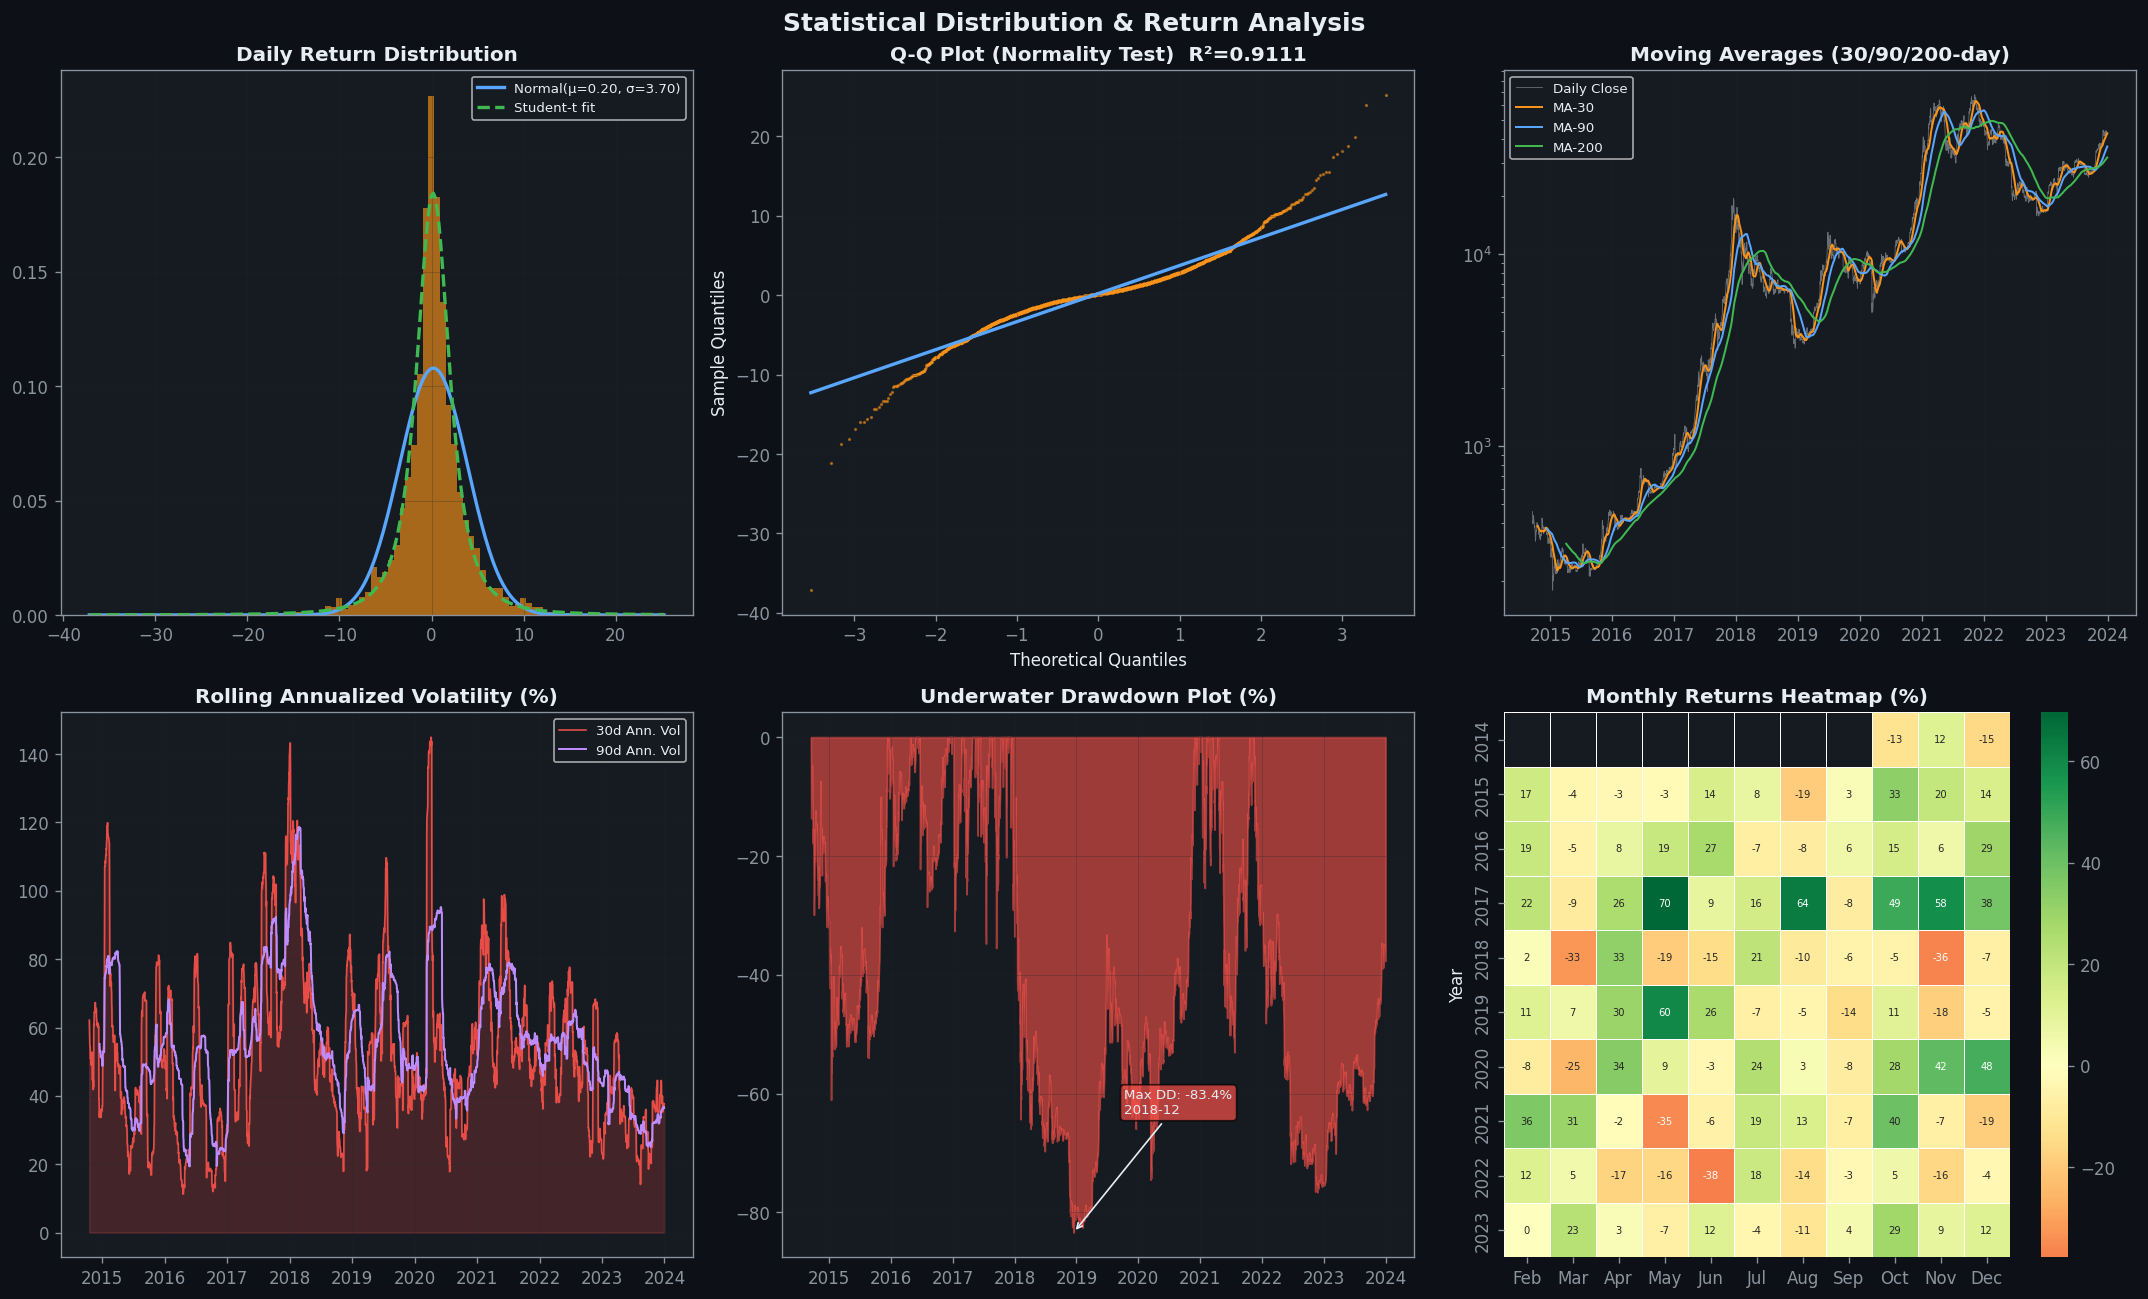

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11), facecolor=BG)
fig.suptitle('Statistical Distribution & Return Analysis', fontsize=15, fontweight='bold', color=WHITE)

# 1) Return distribution
ax = axes[0, 0]
ax.hist(returns, bins=100, density=True, color=ACCENT, alpha=0.65, edgecolor='none')
mu, sigma = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color=BLUE, linewidth=2, label=f'Normal(μ={mu:.2f}, σ={sigma:.2f})')
ax.plot(x, stats.t.pdf(x, *stats.t.fit(returns)), color=GREEN, linewidth=2, linestyle='--', label='Student-t fit')
ax.set_title('Daily Return Distribution'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 2) Q-Q Plot
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(returns, dist='norm')
ax.scatter(osm, osr, s=1, color=ACCENT, alpha=0.5)
ax.plot(osm, slope * np.array(osm) + intercept, color=BLUE, linewidth=2)
ax.set_title(f'Q-Q Plot (Normality Test)  R²={r**2:.4f}')
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles'); ax.grid(True, alpha=0.3)

# 3) Moving Averages
ax = axes[0, 2]
ax.plot(price.index, price, color=WHITE, linewidth=0.5, alpha=0.4, label='Daily Close')
ax.plot(price.rolling(30).mean(),  color=ACCENT, linewidth=1.2, label='MA-30')
ax.plot(price.rolling(90).mean(),  color=BLUE,   linewidth=1.2, label='MA-90')
ax.plot(price.rolling(200).mean(), color=GREEN,  linewidth=1.2, label='MA-200')
ax.set_title('Moving Averages (30/90/200-day)'); ax.set_yscale('log')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 4) Rolling Volatility
ax = axes[1, 0]
vol30 = returns.rolling(30).std() * np.sqrt(252)
vol90 = returns.rolling(90).std() * np.sqrt(252)
ax.plot(vol30.index, vol30, color=RED,    linewidth=1.0, alpha=0.9, label='30d Ann. Vol')
ax.plot(vol90.index, vol90, color=PURPLE, linewidth=1.2, label='90d Ann. Vol')
ax.fill_between(vol30.index, vol30, alpha=0.2, color=RED)
ax.set_title('Rolling Annualized Volatility (%)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 5) Drawdown
ax = axes[1, 1]
roll_max  = price.cummax()
drawdown  = (price - roll_max) / roll_max * 100
ax.fill_between(drawdown.index, drawdown, 0, color=RED, alpha=0.6)
max_dd_date = drawdown.idxmin()
ax.annotate(f'Max DD: {drawdown.min():.1f}%\n{max_dd_date.strftime("%Y-%m")}',
            xy=(max_dd_date, drawdown.min()), fontsize=8, color=WHITE,
            bbox=dict(boxstyle='round', facecolor=RED, alpha=0.7),
            xytext=(max_dd_date + pd.DateOffset(days=300), drawdown.min() + 20),
            arrowprops=dict(arrowstyle='->', color=WHITE))
ax.set_title('Underwater Drawdown Plot (%)'); ax.grid(True, alpha=0.3)

# 6) Monthly Heatmap
ax = axes[1, 2]
df2 = df.copy()
df2['Year'] = df2.index.year; df2['Month'] = df2.index.month
monthly_ret = df2.groupby(['Year', 'Month'])['Close'].last().unstack()
monthly_pct = monthly_ret.pct_change(axis=1) * 100
monthly_pct.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_pct = monthly_pct.iloc[:, 1:]
sns.heatmap(monthly_pct, ax=ax, cmap='RdYlGn', center=0, fmt='.0f', annot=True,
            annot_kws={'size': 6}, linewidths=0.3, mask=monthly_pct.isnull())
ax.set_title('Monthly Returns Heatmap (%)')

plt.tight_layout()
plt.savefig('fig2_stats.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 3. Stationarity Testing
### ADF + KPSS (Augmented Dickey-Fuller + Kwiatkowski-Phillips-Schmidt-Shin)
| Test | Null Hypothesis | Rejection means |
|------|-----------------|------------------|
| ADF  | Unit root exists (non-stationary) | Series IS stationary |
| KPSS | Series is stationary | Series is NOT stationary |

Using **both** eliminates ambiguity. A series is confirmed stationary only when: ADF rejects H0 AND KPSS fails to reject H0.

In [7]:
from statsmodels.tsa.stattools import adfuller, kpss

def run_stationarity_tests(series, name):
    """Run ADF and KPSS tests and print formatted results."""
    print(f'\n{'='*55}')
    print(f'  Stationarity Tests: {name}')
    print(f'{'='*55}')

    # ADF
    adf = adfuller(series.dropna(), autolag='AIC')
    verdict_adf = '✓ STATIONARY' if adf[1] < 0.05 else '✗ NON-STATIONARY'
    print(f'\nADF Test:')
    print(f'  Test Statistic : {adf[0]:.4f}')
    print(f'  p-value        : {adf[1]:.6f}')
    print(f'  Lags Used      : {adf[2]}')
    print(f'  Critical Values: 1%={adf[4]["1%"]:.3f}, 5%={adf[4]["5%"]:.3f}, 10%={adf[4]["10%"]:.3f}')
    print(f'  Verdict        : {verdict_adf}')

    # KPSS
    kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(series.dropna(), regression='c', nlags='auto')
    verdict_kpss = '✗ NON-STATIONARY' if kpss_p < 0.05 else '✓ STATIONARY'
    print(f'\nKPSS Test:')
    print(f'  Test Statistic : {kpss_stat:.4f}')
    print(f'  p-value        : {kpss_p:.4f}')
    print(f'  Verdict        : {verdict_kpss}')

    return adf, (kpss_stat, kpss_p)

adf_price, kpss_price = run_stationarity_tests(price,     'Raw Close Price')
adf_log,   kpss_log   = run_stationarity_tests(log_price, 'Log Close Price')
adf_ret,   kpss_ret   = run_stationarity_tests(log_ret,   'Log Returns (1st diff of log price)')


  Stationarity Tests: Raw Close Price

ADF Test:
  Test Statistic : -1.3123
  p-value        : 0.623518
  Lags Used      : 29
  Critical Values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  Verdict        : ✗ NON-STATIONARY

KPSS Test:
  Test Statistic : 5.8848
  p-value        : 0.0100
  Verdict        : ✗ NON-STATIONARY

  Stationarity Tests: Log Close Price


C:\Users\sajan\AppData\Local\Temp\ipykernel_15412\164224623.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(series.dropna(), regression='c', nlags='auto')



ADF Test:
  Test Statistic : -0.8401
  p-value        : 0.807052
  Lags Used      : 0
  Critical Values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  Verdict        : ✗ NON-STATIONARY

KPSS Test:
  Test Statistic : 7.9318
  p-value        : 0.0100
  Verdict        : ✗ NON-STATIONARY

  Stationarity Tests: Log Returns (1st diff of log price)


C:\Users\sajan\AppData\Local\Temp\ipykernel_15412\164224623.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(series.dropna(), regression='c', nlags='auto')



ADF Test:
  Test Statistic : -17.6404
  p-value        : 0.000000
  Lags Used      : 9
  Critical Values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  Verdict        : ✓ STATIONARY

KPSS Test:
  Test Statistic : 0.1207
  p-value        : 0.1000
  Verdict        : ✓ STATIONARY


C:\Users\sajan\AppData\Local\Temp\ipykernel_15412\164224623.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(series.dropna(), regression='c', nlags='auto')


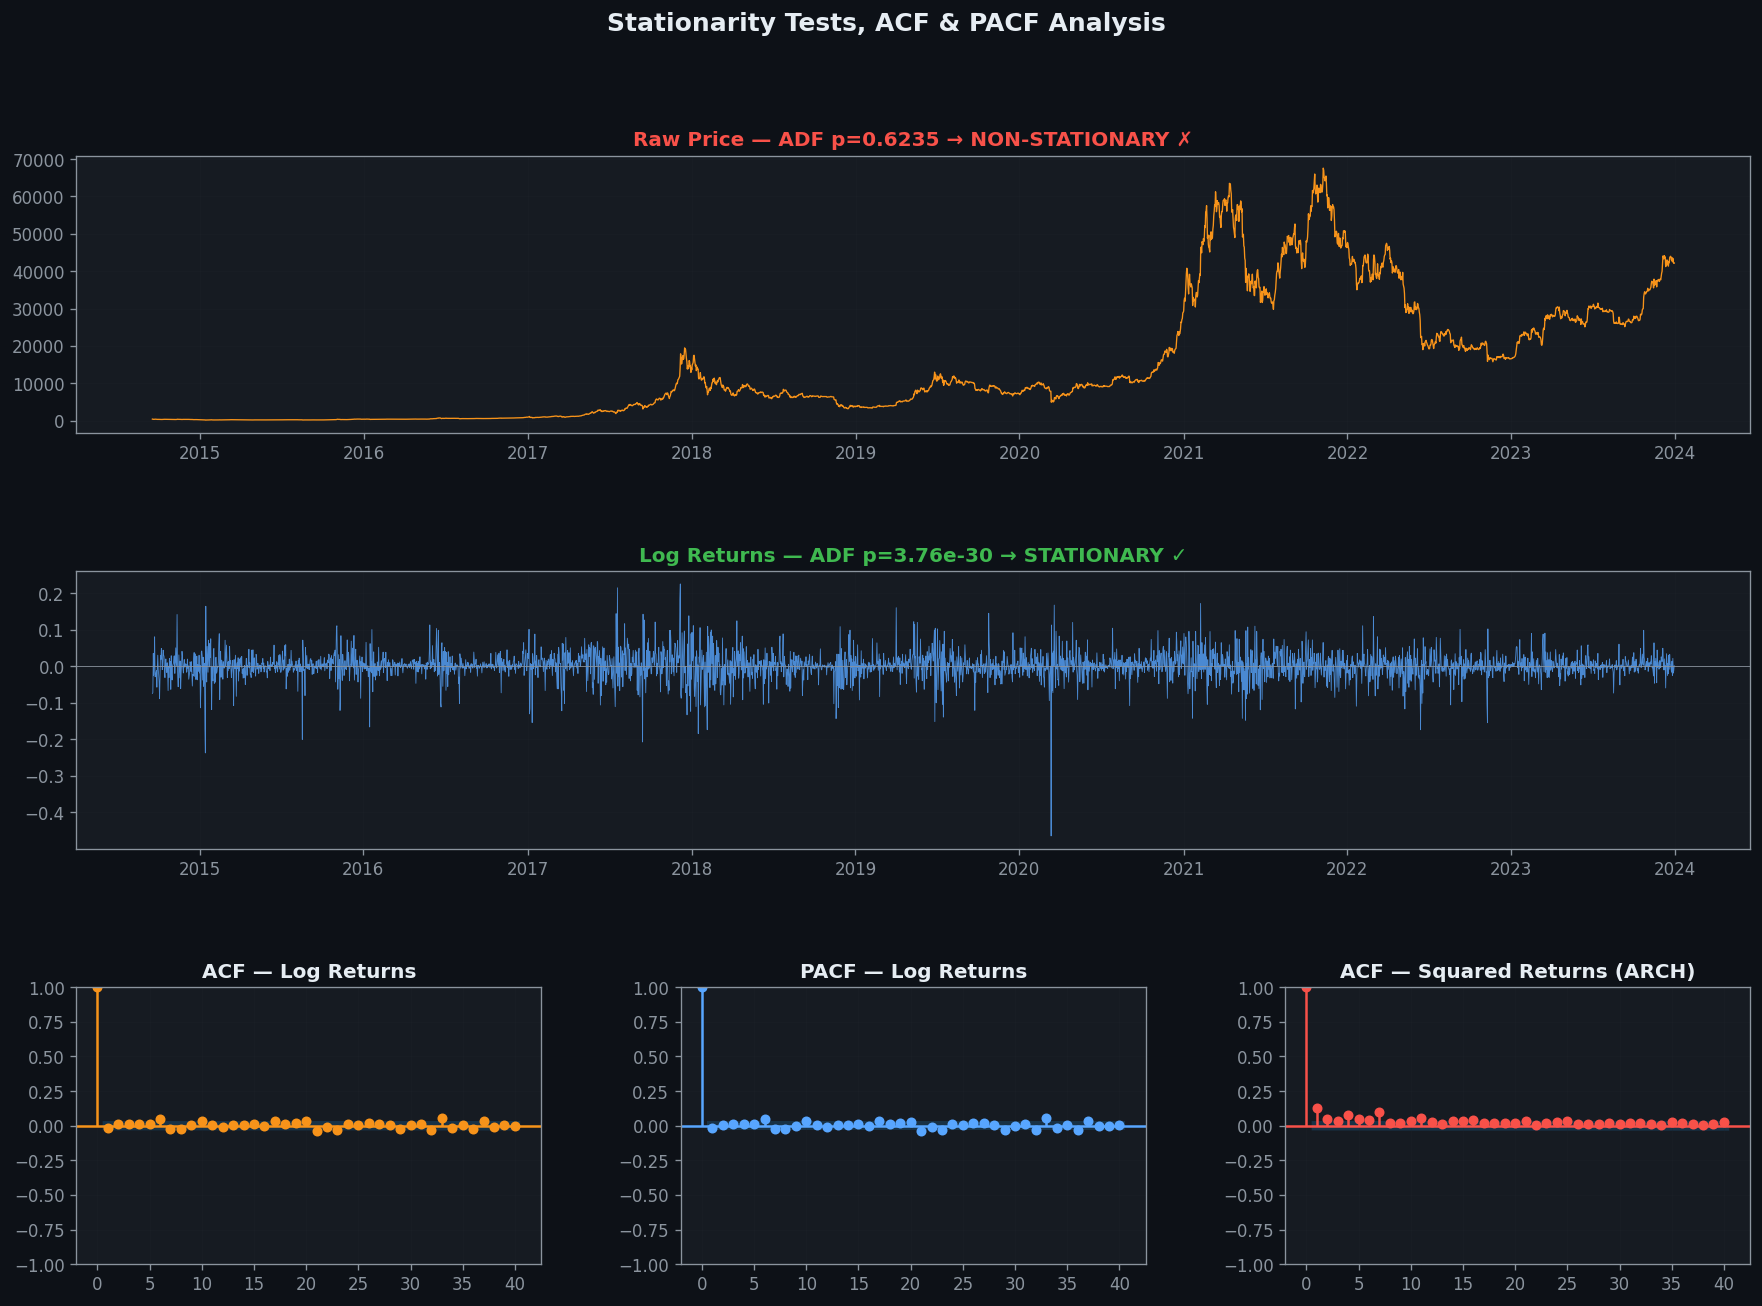

ARCH effect confirmed: squared returns show strong autocorrelation → volatility clustering exists


In [8]:
# ── ACF / PACF + Stationarity Visual ──────────────────
fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle('Stationarity Tests, ACF & PACF Analysis', fontsize=15, fontweight='bold', color=WHITE)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.3)

# Raw price
ax = fig.add_subplot(gs[0, :])
ax.plot(price.index, price, color=ACCENT, linewidth=0.8)
ax.set_title(f'Raw Price — ADF p={adf_price[1]:.4f} → NON-STATIONARY ✗', color=RED)
ax.grid(True, alpha=0.3)

# Log returns
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(log_ret.index, log_ret, color=BLUE, linewidth=0.5, alpha=0.8)
ax2.axhline(0, color=GRAY, linewidth=0.5)
ax2.set_title(f'Log Returns — ADF p={adf_ret[1]:.2e} → STATIONARY ✓', color=GREEN)
ax2.grid(True, alpha=0.3)

# ACF log returns
ax3 = fig.add_subplot(gs[2, 0])
plot_acf(log_ret, lags=40, ax=ax3, color=ACCENT, vlines_kwargs={'colors': ACCENT})
ax3.set_title('ACF — Log Returns'); ax3.grid(True, alpha=0.3)

# PACF log returns
ax4 = fig.add_subplot(gs[2, 1])
plot_pacf(log_ret, lags=40, ax=ax4, color=BLUE, vlines_kwargs={'colors': BLUE})
ax4.set_title('PACF — Log Returns'); ax4.grid(True, alpha=0.3)

# ACF squared (ARCH effect)
ax5 = fig.add_subplot(gs[2, 2])
plot_acf(log_ret**2, lags=40, ax=ax5, color=RED, vlines_kwargs={'colors': RED})
ax5.set_title('ACF — Squared Returns (ARCH)')
ax5.grid(True, alpha=0.3)

plt.savefig('fig3_stationarity.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('ARCH effect confirmed: squared returns show strong autocorrelation → volatility clustering exists')

## 4. Seasonal Decomposition — STL
### STL (Seasonal-Trend decomposition via LOESS)
**Hyperparameters:**
- `period=52` → Annual seasonality on weekly data
- `robust=True` → Bisquare weighting downweights outliers (critical for crypto!)

**Why STL over classical decomposition?**
Classical additive/multiplicative decomposition uses symmetric moving averages — outliers contaminate trend estimates. STL's LOESS smoother is robust to extreme values like Bitcoin's ±40% single-day moves.

In [9]:
# ── STL on weekly resampled data ──────────────────────
price_weekly = price.resample('W').last()
stl = STL(price_weekly, period=52, robust=True)
res = stl.fit()

print(f'Weekly observations: {len(price_weekly)}')
print(f'Trend range: ${res.trend.min():,.0f} – ${res.trend.max():,.0f}')
print(f'Seasonal amplitude: ±${abs(res.seasonal).max():,.0f}')
print(f'Residual std: ${res.resid.std():,.0f}')

# Variance explained
var_trend    = res.trend.var()
var_seasonal = res.seasonal.var()
var_resid    = res.resid.var()
total_var    = price_weekly.var()
print(f'\nVariance decomposition:')
print(f'  Trend:    {var_trend/total_var*100:.1f}%')
print(f'  Seasonal: {var_seasonal/total_var*100:.1f}%')
print(f'  Residual: {var_resid/total_var*100:.1f}%')

Weekly observations: 485
Trend range: $223 – $36,049
Seasonal amplitude: ±$20,096
Residual std: $9,896

Variance decomposition:
  Trend:    66.5%
  Seasonal: 7.6%
  Residual: 37.2%


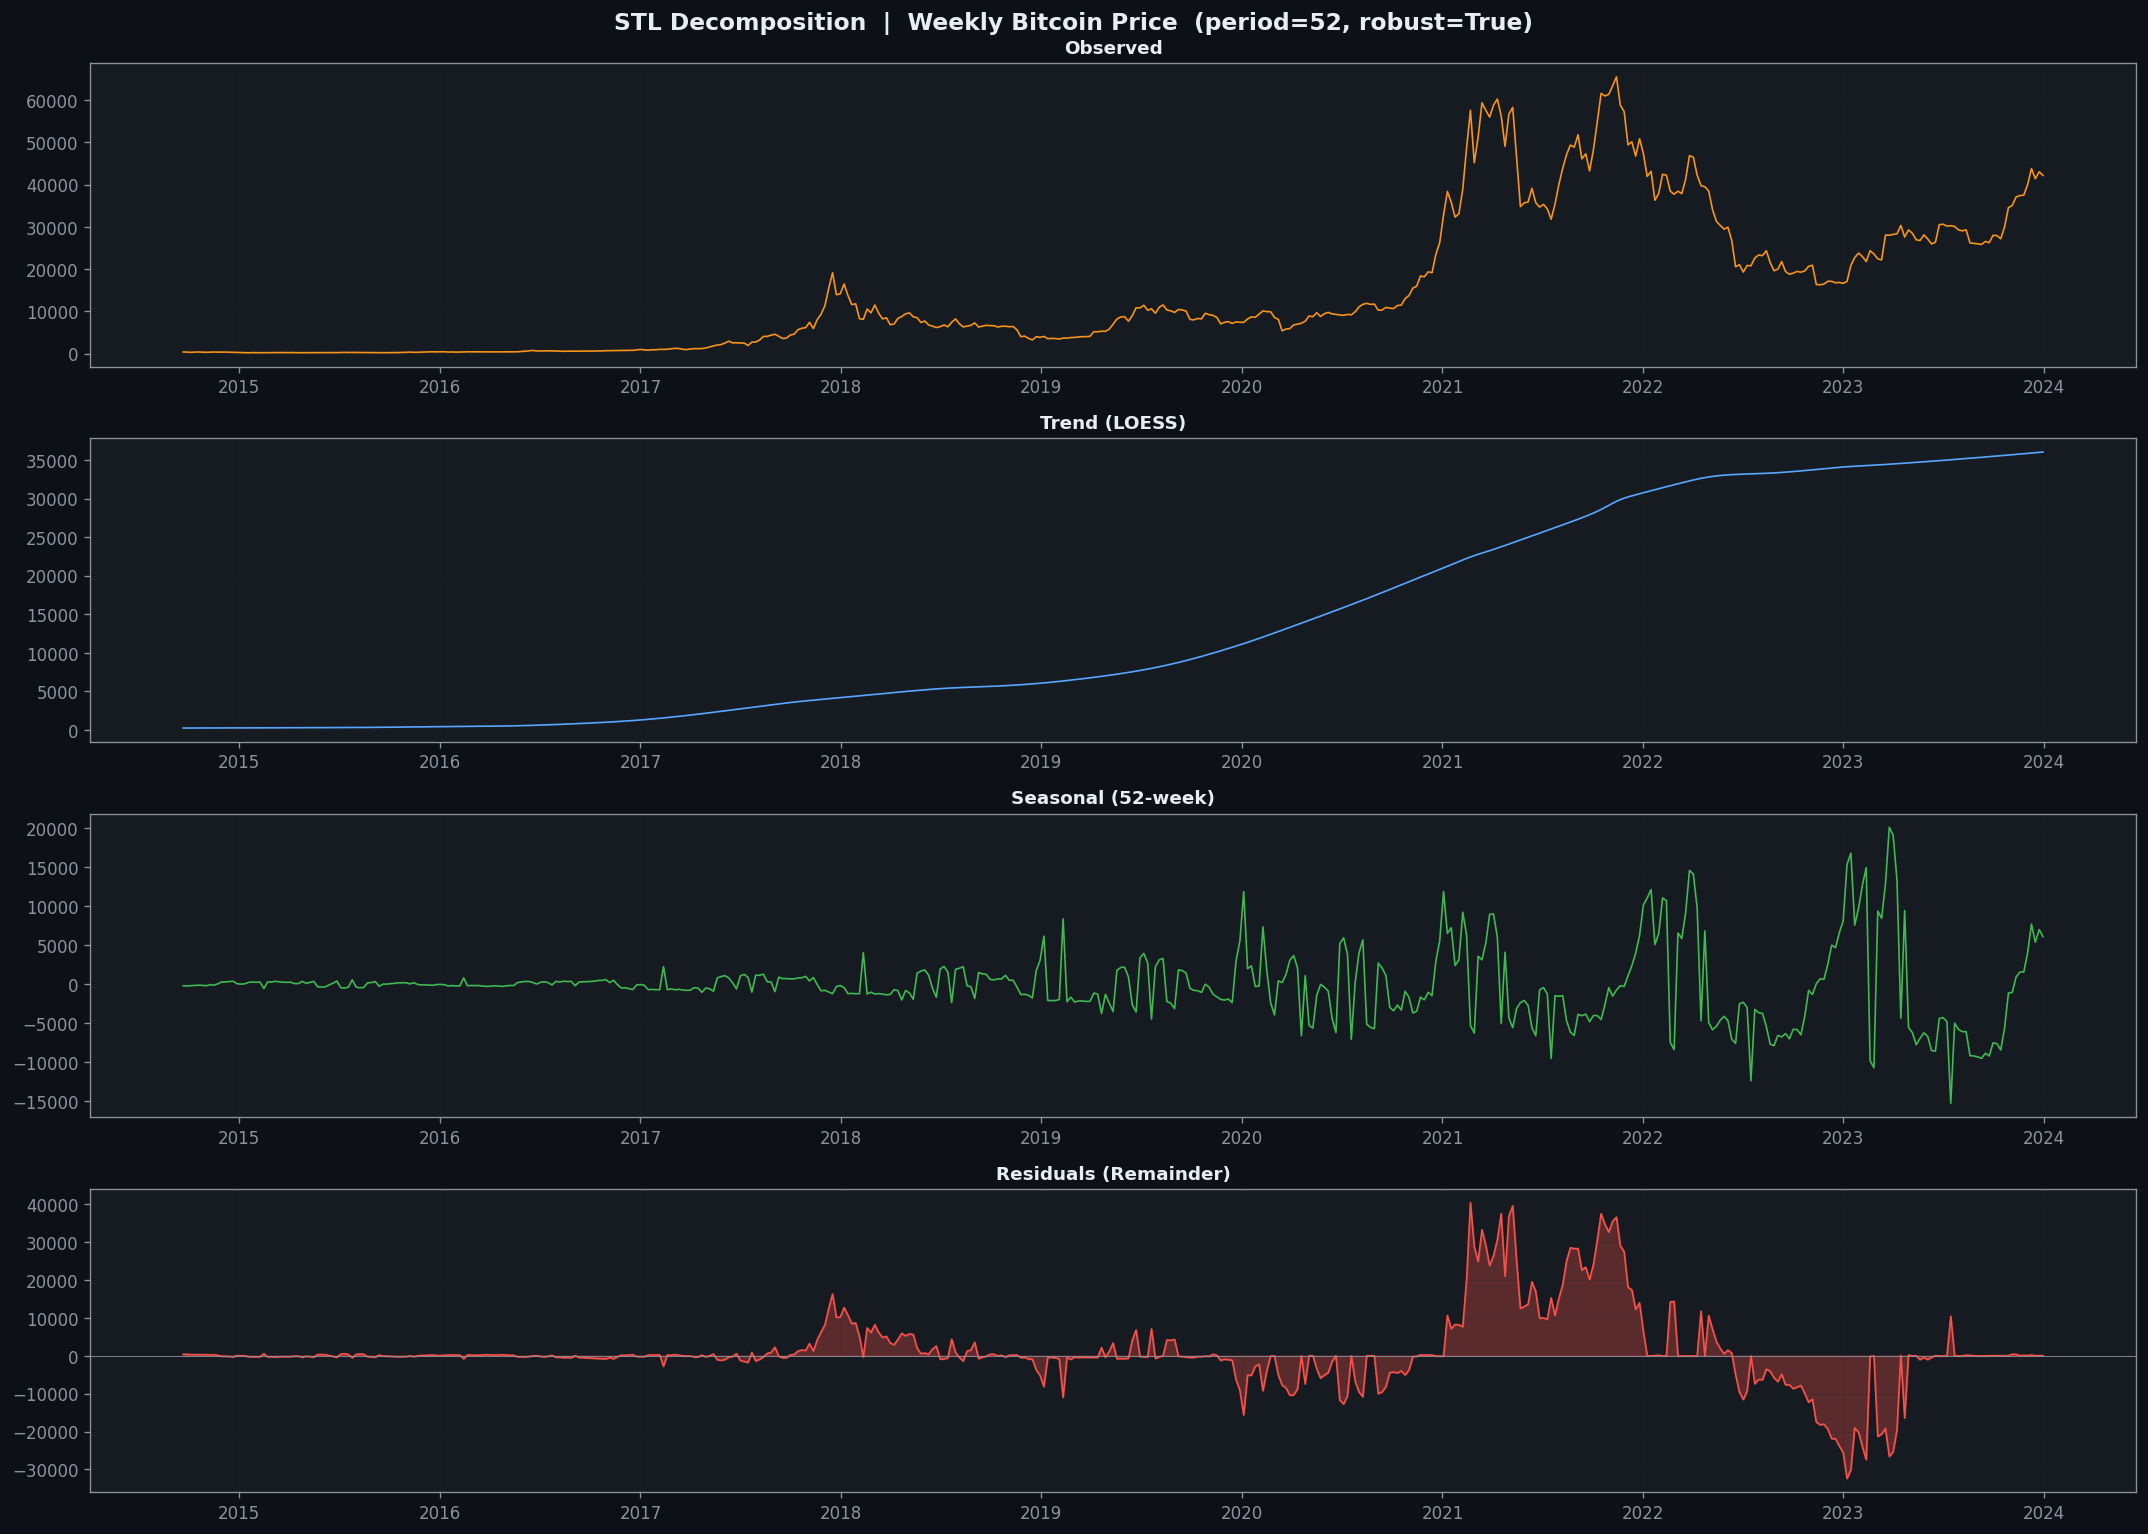

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(18, 13), facecolor=BG)
fig.suptitle('STL Decomposition  |  Weekly Bitcoin Price  (period=52, robust=True)',
             fontsize=14, fontweight='bold', color=WHITE)

components = [
    (price_weekly, 'Observed',              ACCENT),
    (res.trend,    'Trend (LOESS)',          BLUE),
    (res.seasonal, 'Seasonal (52-week)',     GREEN),
    (res.resid,    'Residuals (Remainder)', RED),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.0)
    if title.startswith('Residual'):
        ax.fill_between(data.index, data.values, 0, color=color, alpha=0.3)
        ax.axhline(0, color=GRAY, linewidth=0.5)
    ax.set_title(title, fontsize=11); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_decomp.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 5. Forecasting Models
### Train/Test Split Strategy
- **85% train** (2,883 days) → **15% test** (509 days)
- Sequential split — **NO shuffle** — preserves temporal causality
- Shuffling in time series = **look-ahead bias** = inflated metrics

### Models Implemented
| # | Model | Type | d (differencing) |
|---|-------|------|---|
| 1 | ARIMA(1,1,1) | Statistical | d=1 (log price) |
| 2 | Holt-Winters Damped | Statistical | None (raw price) |
| 3 | Random Forest | ML Ensemble | None (lag features) |
| 4 | Gradient Boosting | ML Ensemble | None (lag features) |

In [11]:
# ── Train / Test Split ────────────────────────────────
train_size = int(len(price) * 0.85)
train, test = price[:train_size], price[train_size:]
log_train, log_test = log_price[:train_size], log_price[train_size:]

print(f'Train: {len(train)} observations ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test:  {len(test)}  observations ({test.index[0].date()} → {test.index[-1].date()})')
print(f'Train price range: ${train.min():,.0f} – ${train.max():,.0f}')
print(f'Test  price range: ${test.min():,.0f}  – ${test.max():,.0f}')

model_results = {}

Train: 2883 observations (2014-09-17 → 2022-08-08)
Test:  509  observations (2022-08-09 → 2023-12-30)
Train price range: $178 – $67,567
Test  price range: $15,787  – $44,167


### Model 1: ARIMA(1,1,1)
**Hyperparameters:** p=1 (AR order), d=1 (differencing on log-price), q=1 (MA order), optimiser=MLE, fit on log-transformed prices to stabilise variance.

In [12]:
print('Fitting ARIMA(1,1,1)...')

# ── Hyperparameters ──
ARIMA_ORDER = (1, 1, 1)  # (p, d, q)

arima_model = ARIMA(log_train, order=ARIMA_ORDER).fit()
print(arima_model.summary())

arima_pred_log = arima_model.forecast(steps=len(test))
arima_pred     = np.exp(arima_pred_log)  # Back-transform
arima_pred.index = test.index

mae_arima  = mean_absolute_error(test, arima_pred)
mape_arima = mean_absolute_percentage_error(test, arima_pred) * 100
rmse_arima = np.sqrt(mean_squared_error(test, arima_pred))

model_results['ARIMA(1,1,1)'] = {'pred': arima_pred, 'mae': mae_arima, 'mape': mape_arima, 'rmse': rmse_arima}
print(f'\nARIMA Results → MAPE: {mape_arima:.2f}%  |  MAE: ${mae_arima:,.0f}  |  RMSE: ${rmse_arima:,.0f}')

Fitting ARIMA(1,1,1)...


C:\Users\sajan\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\sajan\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\sajan\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              log_close   No. Observations:                 2883
Model:                 ARIMA(1, 1, 1)   Log Likelihood                5254.164
Date:                Mon, 08 Jun 2026   AIC                         -10502.327
Time:                        19:03:29   BIC                         -10484.429
Sample:                    09-17-2014   HQIC                        -10495.876
                         - 08-08-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0887      0.823     -0.108      0.914      -1.702       1.524
ma.L1          0.0703      0.822      0.086      0.932      -1.542       1.682
sigma2         0.0015   1.61e-05     95.128      0.0

### Model 2: Holt-Winters (Damped Additive Trend)
**Hyperparameters:** trend='add' (additive trend component), seasonal=None (no explicit seasonality), damped_trend=True (prevents explosive long-run forecasts), optimised=True (auto-optimise alpha/beta/phi via MLE).

In [13]:
print('Fitting Holt-Winters (Damped Additive)...')

hw_model = ExponentialSmoothing(
    train,
    trend='add',          # Additive trend component
    seasonal=None,        # No explicit seasonality modelled
    damped_trend=True,    # Phi parameter dampens trend → prevents over-extrapolation
).fit(optimized=True)    # MLE optimisation of smoothing parameters

print(f'Alpha (level):   {hw_model.params["smoothing_level"]:.4f}')
print(f'Beta  (trend):   {hw_model.params["smoothing_trend"]:.4f}')
print(f'Phi   (damping): {hw_model.params["damping_trend"]:.4f}')

hw_pred = hw_model.forecast(steps=len(test))
hw_pred.index = test.index

mae_hw  = mean_absolute_error(test, hw_pred)
mape_hw = mean_absolute_percentage_error(test, hw_pred) * 100
rmse_hw = np.sqrt(mean_squared_error(test, hw_pred))

model_results['Holt-Winters'] = {'pred': hw_pred, 'mae': mae_hw, 'mape': mape_hw, 'rmse': rmse_hw}
print(f'\nHolt-Winters Results → MAPE: {mape_hw:.2f}%  |  MAE: ${mae_hw:,.0f}  |  RMSE: ${rmse_hw:,.0f}')

Fitting Holt-Winters (Damped Additive)...
Alpha (level):   0.9641
Beta  (trend):   0.0100
Phi   (damping): 0.9644

Holt-Winters Results → MAPE: 20.71%  |  MAE: $5,485  |  RMSE: $7,012


C:\Users\sajan\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### Feature Engineering for ML Models
30 features created from log-price:
- **8 lag features**: t-1, t-2, t-3, t-5, t-7, t-14, t-21, t-30
- **8 rolling stats**: 4 windows (7/14/30/60) × (mean + std)
- **2 momentum**: price ratio over 7d and 30d windows
- **2 calendar**: day-of-week, month

**Why these features?** Lag-1 captures the dominant AR(1) structure (74.6% importance). Rolling stats capture trend and volatility regime. Momentum captures medium-term directional bias. Calendar features capture any day-of-week or monthly seasonality.

In [14]:
def make_features(series):
    """Engineer lag, rolling, momentum, and calendar features from a price series."""
    df_ml = pd.DataFrame({'price': series})

    # Lag features
    for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
        df_ml[f'lag_{lag}'] = series.shift(lag)

    # Rolling mean & std
    for win in [7, 14, 30, 60]:
        df_ml[f'ma_{win}']  = series.rolling(win).mean()
        df_ml[f'std_{win}'] = series.rolling(win).std()

    # Momentum
    df_ml['momentum_7']  = series / series.shift(7)  - 1
    df_ml['momentum_30'] = series / series.shift(30) - 1

    # Calendar
    df_ml['day_of_week'] = pd.to_datetime(series.index).dayofweek
    df_ml['month']       = pd.to_datetime(series.index).month

    return df_ml.dropna()

full_feat = make_features(log_price)
full_feat['target'] = full_feat['price'].shift(-1)
full_feat = full_feat.dropna()

X = full_feat.drop(['price', 'target'], axis=1)
y = full_feat['target']

X_train = X[X.index < test.index[0]]
y_train = y[y.index < test.index[0]]
X_test  = X[X.index >= test.index[0]]
y_test  = y[y.index >= test.index[0]]
actual_test = np.exp(y_test.values)

print(f'Feature matrix: {X.shape} ({X.shape[1]} features)')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features: {list(X.columns)}')

Feature matrix: (3332, 20) (20 features)
X_train: (2824, 20) | X_test: (508, 20)
Features: ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_30', 'ma_7', 'std_7', 'ma_14', 'std_14', 'ma_30', 'std_30', 'ma_60', 'std_60', 'momentum_7', 'momentum_30', 'day_of_week', 'month']


### Model 3: Random Forest
**Hyperparameters:** n_estimators=200 (200 trees, balance of accuracy vs speed), max_depth=10 (prevents overfitting), min_samples_split=5 (regularisation), random_state=42.

In [15]:
print('Fitting Random Forest...')

rf = RandomForestRegressor(
    n_estimators=200,    # Number of trees — more = better but diminishing returns
    max_depth=10,        # Max tree depth — limits overfitting
    min_samples_split=5, # Min samples to split — additional regularisation
    random_state=42,
    n_jobs=-1            # Use all CPU cores
)
rf.fit(X_train, y_train)

rf_pred_log = rf.predict(X_test)
rf_pred     = np.exp(rf_pred_log)

mae_rf  = mean_absolute_error(actual_test, rf_pred)
mape_rf = mean_absolute_percentage_error(actual_test, rf_pred) * 100
rmse_rf = np.sqrt(mean_squared_error(actual_test, rf_pred))

model_results['Random Forest'] = {
    'pred': pd.Series(rf_pred, index=X_test.index),
    'mae': mae_rf, 'mape': mape_rf, 'rmse': rmse_rf
}

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(f'RF Results → MAPE: {mape_rf:.2f}%  |  MAE: ${mae_rf:,.0f}  |  RMSE: ${rmse_rf:,.0f}')
print(f'\nTop 10 Features:')
print(feat_imp.head(10).to_string())

Fitting Random Forest...
RF Results → MAPE: 5.76%  |  MAE: $1,380  |  RMSE: $1,671

Top 10 Features:
lag_1     0.745556
ma_7      0.075566
lag_2     0.058797
ma_60     0.029027
ma_14     0.025409
ma_30     0.018996
lag_14    0.015840
lag_30    0.015762
lag_21    0.007907
lag_3     0.006083


### Model 4: Gradient Boosting (Best Performer)
**Hyperparameters:** n_estimators=300 (sequential trees), max_depth=5 (shallower trees than RF — boosting corrects errors iteratively), learning_rate=0.05 (shrinkage — smaller = more regularised), subsample=0.8 (stochastic gradient boosting, reduces overfitting).

In [16]:
print('Fitting Gradient Boosting...')

gb = GradientBoostingRegressor(
    n_estimators=300,    # Sequential ensemble — each tree corrects previous errors
    max_depth=5,         # Shallower than RF — boosting compensates with more trees
    learning_rate=0.05,  # Shrinkage parameter — lower = more regularised, needs more trees
    subsample=0.8,       # Stochastic GB — sample 80% of data per tree (reduces variance)
    random_state=42
)
gb.fit(X_train, y_train)

gb_pred_log = gb.predict(X_test)
gb_pred     = np.exp(gb_pred_log)

mae_gb  = mean_absolute_error(actual_test, gb_pred)
mape_gb = mean_absolute_percentage_error(actual_test, gb_pred) * 100
rmse_gb = np.sqrt(mean_squared_error(actual_test, gb_pred))

model_results['Gradient Boosting'] = {
    'pred': pd.Series(gb_pred, index=X_test.index),
    'mae': mae_gb, 'mape': mape_gb, 'rmse': rmse_gb
}
print(f'GB Results → MAPE: {mape_gb:.2f}%  |  MAE: ${mae_gb:,.0f}  |  RMSE: ${rmse_gb:,.0f}')

Fitting Gradient Boosting...
GB Results → MAPE: 4.78%  |  MAE: $1,121  |  RMSE: $1,372


### Model Comparison Visualisation

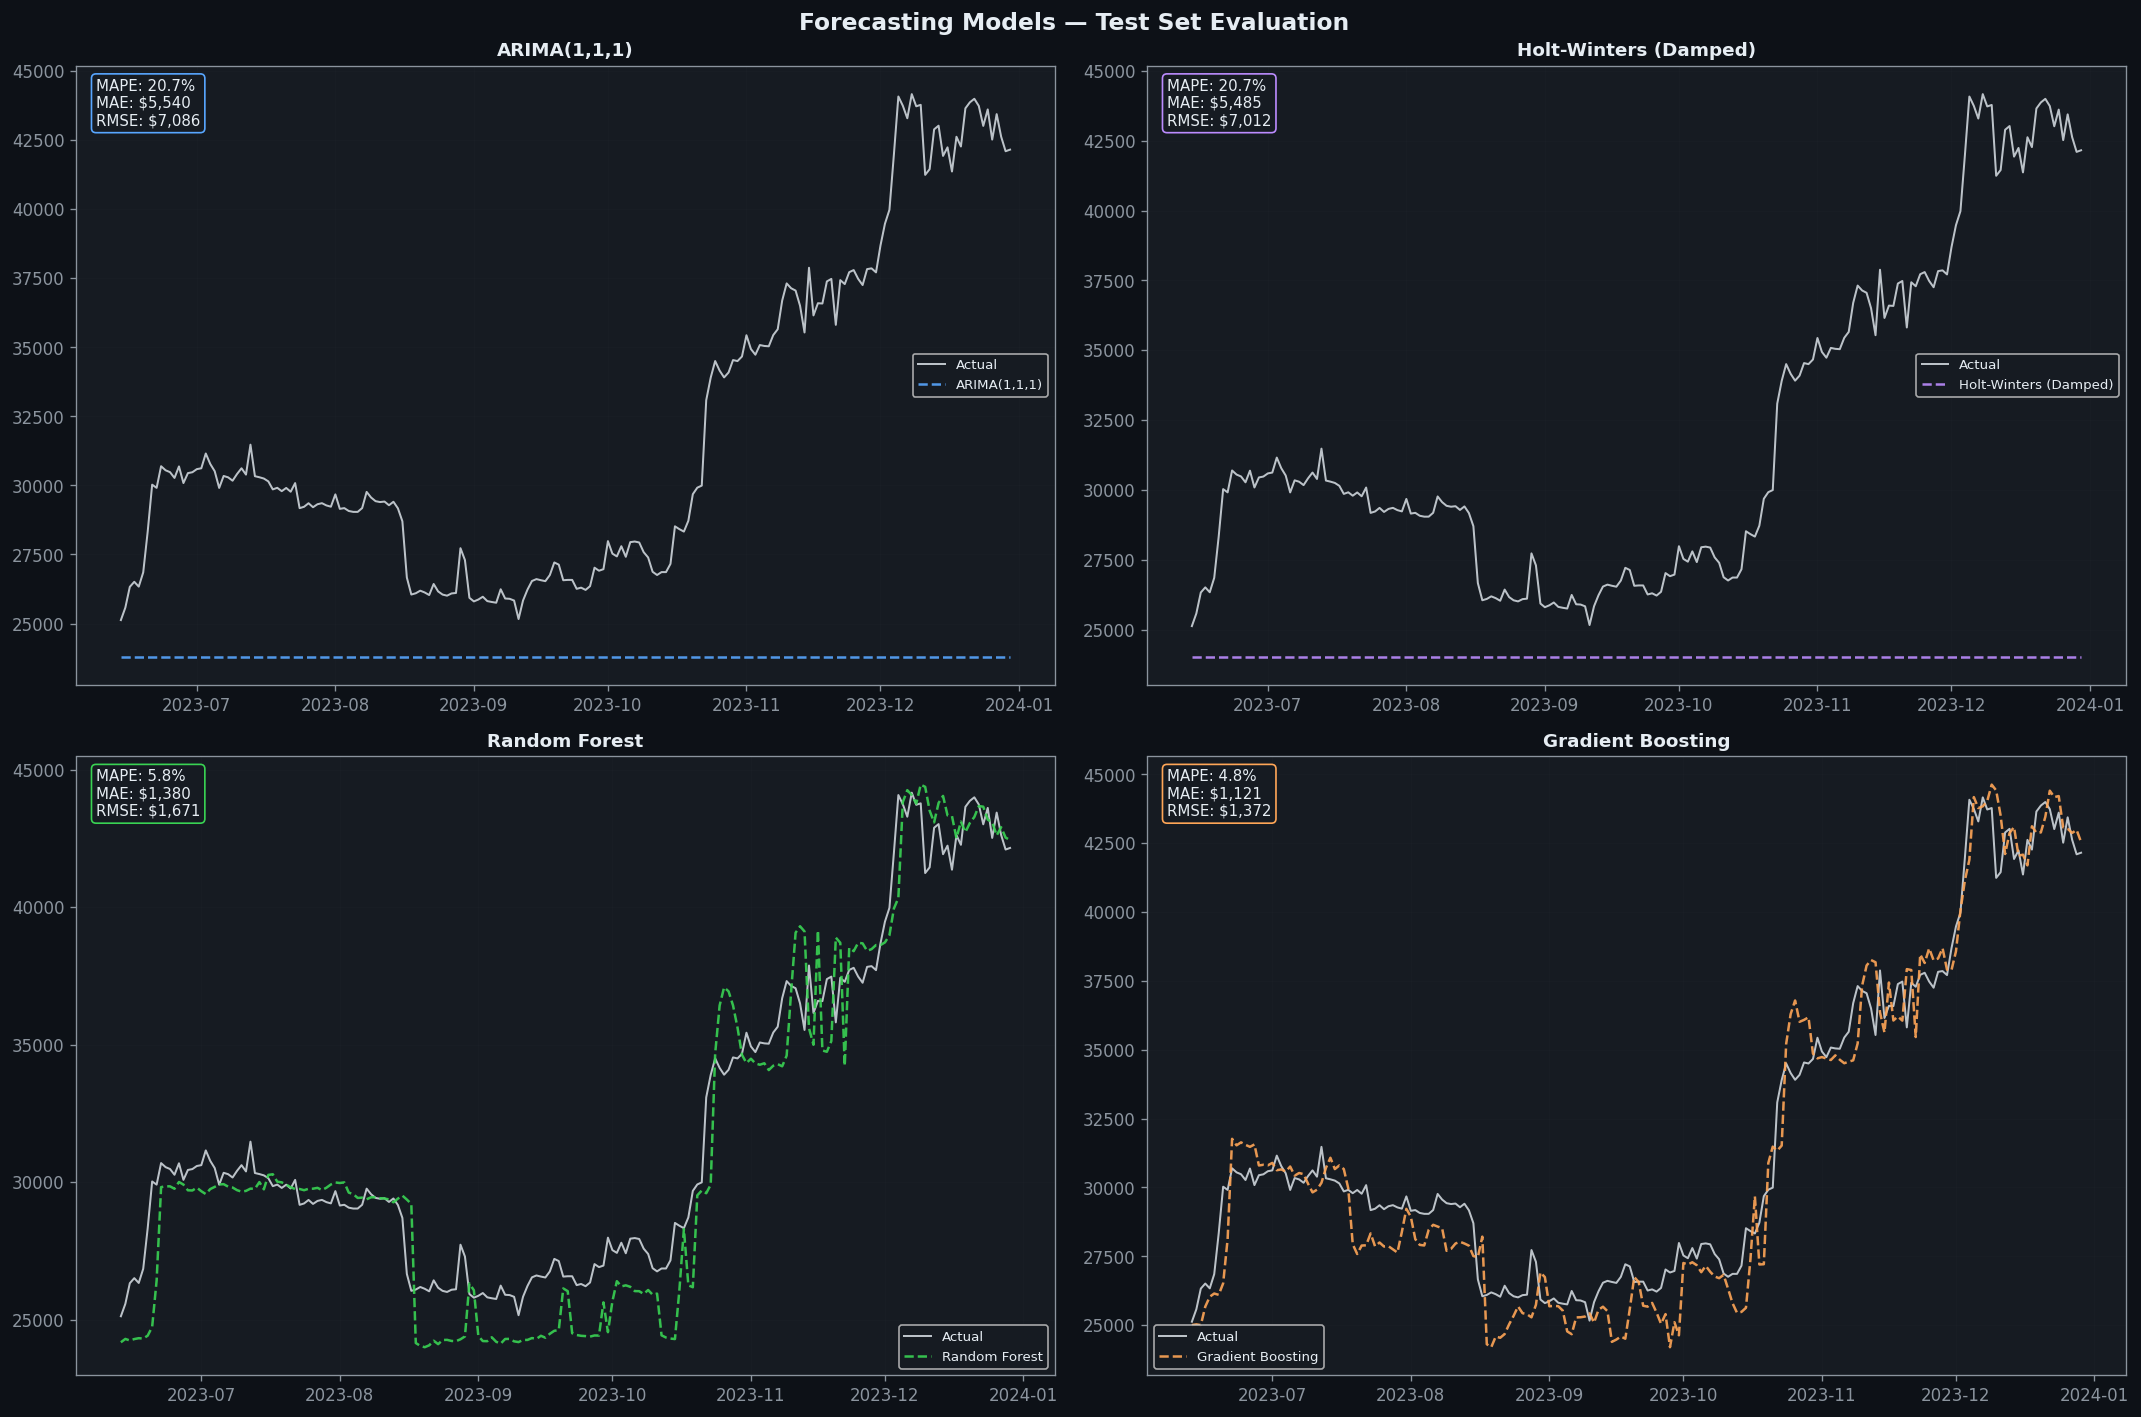


── Model Leaderboard ──────────────────────────────
Model                         MAPE          MAE         RMSE
────────────────────────────────────────────────────────────
Gradient Boosting             4.8%       $1,121       $1,372
Random Forest                 5.8%       $1,380       $1,671
Holt-Winters                 20.7%       $5,485       $7,012
ARIMA(1,1,1)                 20.7%       $5,540       $7,086


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BG)
fig.suptitle('Forecasting Models — Test Set Evaluation',
             fontsize=14, fontweight='bold', color=WHITE)

model_configs = [
    ('ARIMA(1,1,1)',          'ARIMA(1,1,1)',     model_results['ARIMA(1,1,1)']['pred'],      test,        BLUE),
    ('Holt-Winters (Damped)', 'Holt-Winters',     model_results['Holt-Winters']['pred'],      test,        PURPLE),
    ('Random Forest',         'Random Forest',    model_results['Random Forest']['pred'],     actual_test, TEAL),
    ('Gradient Boosting',     'Gradient Boosting',model_results['Gradient Boosting']['pred'], actual_test, '#ffa657'),
]

for ax, (display_name, result_key, pred, actual, color) in zip(axes.flatten(), model_configs):
    n = min(200, len(pred))
    idx = pred.index[-n:]

    # Align actual values properly
    if hasattr(actual, 'index'):
        act_vals = actual.loc[idx[0]:idx[-1]]
        act_idx = act_vals.index
        act_plot_vals = act_vals.values
    else:
        act_vals = actual[-n:]
        act_idx = idx
        act_plot_vals = act_vals

    ax.plot(
        act_idx,
        act_plot_vals,
        color=WHITE,
        linewidth=1.2,
        alpha=0.8,
        label='Actual'
    )

    ax.plot(
        idx,
        pred.values[-n:],
        color=color,
        linewidth=1.5,
        linestyle='--',
        label=display_name,
        alpha=0.9
    )

    r = model_results[result_key]

    ax.set_title(display_name, fontsize=11, color=WHITE)

    ax.text(
        0.02, 0.98,
        f'MAPE: {r["mape"]:.1f}%\nMAE: ${r["mae"]:,.0f}\nRMSE: ${r["rmse"]:,.0f}',
        transform=ax.transAxes,
        fontsize=9,
        va='top',
        bbox=dict(boxstyle='round', facecolor=CARD, edgecolor=color),
        color=WHITE
    )

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_models.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


# ── Leaderboard ────────────────────────────────────────
print('\n── Model Leaderboard ──────────────────────────────')
print(f'{"Model":<25} {"MAPE":>8} {"MAE":>12} {"RMSE":>12}')
print('─' * 60)

for name in sorted(model_results, key=lambda x: model_results[x]['mape']):
    r = model_results[name]
    print(
        f'{name:<25} '
        f'{r["mape"]:>7.1f}% '
        f'{"$" + f"{r["mae"]:,.0f}":>12} '
        f'{"$" + f"{r["rmse"]:,.0f}":>12}'
    )

## 6. Risk Analysis
### Value at Risk (VaR) and Conditional VaR (CVaR / Expected Shortfall)
- **VaR(α)**: Maximum expected loss over a given period at confidence level α
- **CVaR(α)**: *Average* loss in the worst (1-α)% of cases — more informative than VaR
- **Why CVaR > VaR**: VaR says 'you won't lose more than X on 95% of days'. CVaR says 'on the 5% of days when you do exceed VaR, the average loss is Y'.

In [18]:
# ── VaR & CVaR (Historical Simulation) ───────────────
var_95  = np.percentile(returns, 5)
var_99  = np.percentile(returns, 1)
cvar_95 = returns[returns <= var_95].mean()
cvar_99 = returns[returns <= var_99].mean()

# ── Full Risk Dashboard ────────────────────────────────
skewness = returns.skew()
kurtosis = returns.kurtosis()
ann_vol  = log_ret.std() * np.sqrt(252) * 100
cagr     = (price.iloc[-1] / price.iloc[0]) ** (1 / 9.28) - 1
sharpe   = (log_ret.mean() - 0.02/252) / log_ret.std() * np.sqrt(252)
max_dd   = ((price - price.cummax()) / price.cummax() * 100).min()

print('── Risk Metrics Dashboard ──────────────────────────')
print(f'VaR  95%  (daily): {var_95:.2f}%')
print(f'VaR  99%  (daily): {var_99:.2f}%')
print(f'CVaR 95%  (daily): {cvar_95:.2f}%')
print(f'CVaR 99%  (daily): {cvar_99:.2f}%')
print(f'Annualised Vol:    {ann_vol:.1f}%')
print(f'CAGR (9.28y):      {cagr*100:.1f}%')
print(f'Sharpe Ratio:      {sharpe:.2f}')
print(f'Max Drawdown:      {max_dd:.1f}%')
print(f'Skewness:          {skewness:.3f}')
print(f'Excess Kurtosis:   {kurtosis:.2f}')
print(f'Best Day:          +{returns.max():.2f}%')
print(f'Worst Day:         {returns.min():.2f}%')

── Risk Metrics Dashboard ──────────────────────────
VaR  95%  (daily): -5.76%
VaR  99%  (daily): -10.39%
CVaR 95%  (daily): -8.70%
CVaR 99%  (daily): -13.95%
Annualised Vol:    59.2%
CAGR (9.28y):      62.8%
Sharpe Ratio:      0.53
Max Drawdown:      -83.4%
Skewness:          -0.139
Excess Kurtosis:   7.58
Best Day:          +25.25%
Worst Day:         -37.17%


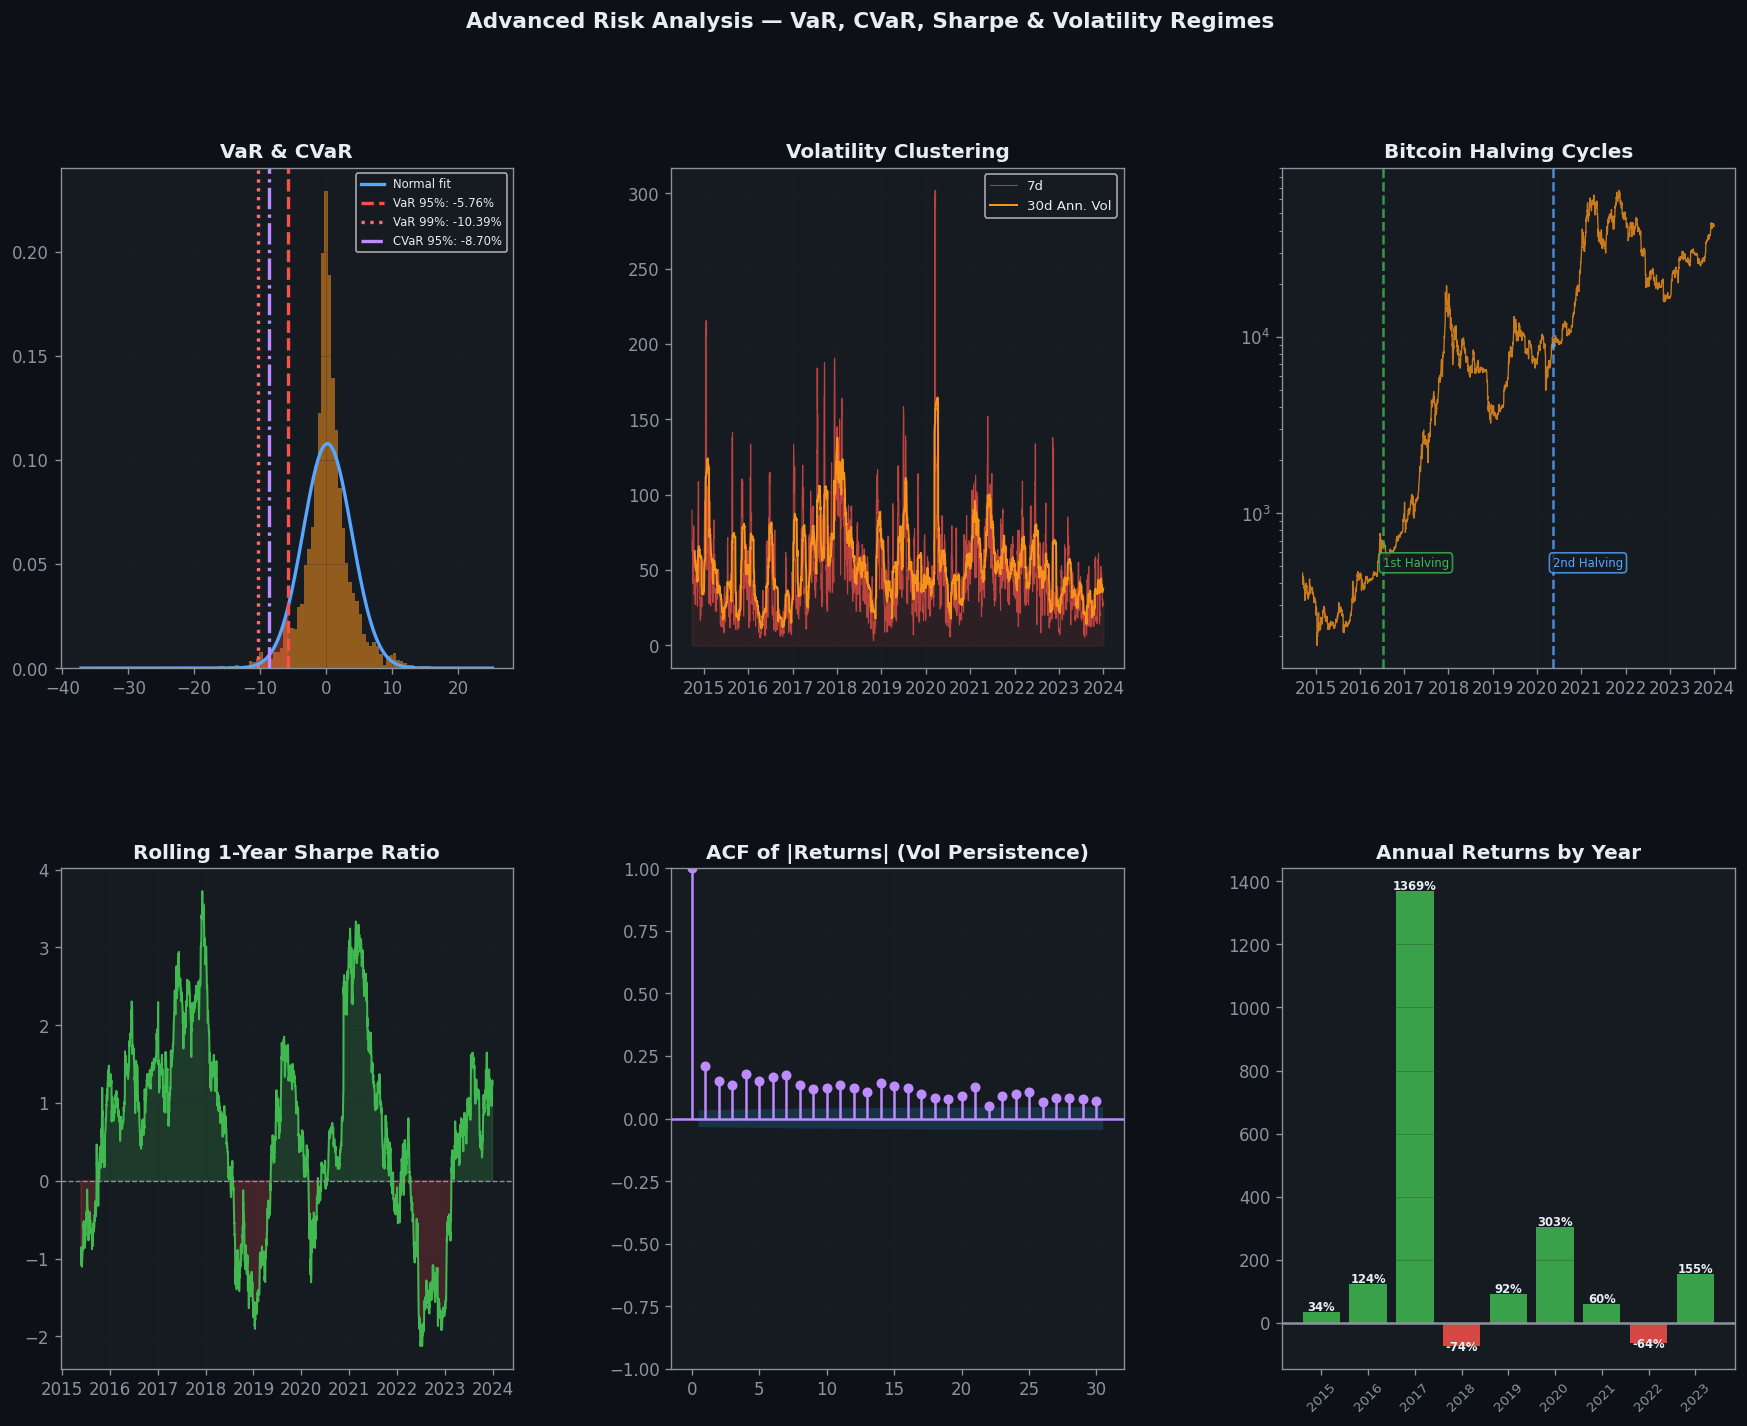

In [21]:
fig = plt.figure(figsize=(18, 13), facecolor=BG)
fig.suptitle('Advanced Risk Analysis — VaR, CVaR, Sharpe & Volatility Regimes',
             fontsize=13, fontweight='bold', color=WHITE)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1) VaR/CVaR
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(returns, bins=120, density=True, color=ACCENT, alpha=0.55, edgecolor='none')
mu_r, sig_r = returns.mean(), returns.std()
xr = np.linspace(returns.min(), returns.max(), 400)
ax1.plot(xr, stats.norm.pdf(xr, mu_r, sig_r), color=BLUE, linewidth=2, label='Normal fit')
ax1.axvline(var_95, color=RED,    linewidth=2, linestyle='--', label=f'VaR 95%: {var_95:.2f}%')
ax1.axvline(var_99, color='#ff6b6b', linewidth=2, linestyle=':', label=f'VaR 99%: {var_99:.2f}%')
ax1.axvline(cvar_95, color=PURPLE, linewidth=2, linestyle='-.', label=f'CVaR 95%: {cvar_95:.2f}%')
ax1.fill_between(xr[xr<=var_95], 0, stats.norm.pdf(xr[xr<=var_95], mu_r, sig_r), color=RED, alpha=0.3)
ax1.set_title('VaR & CVaR'); ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

# 2) Volatility Clustering
ax2 = fig.add_subplot(gs[0, 1])
vol7  = log_ret.rolling(7).std()  * np.sqrt(252) * 100
vol30 = log_ret.rolling(30).std() * np.sqrt(252) * 100
ax2.plot(vol7.index,  vol7,  color=RED,    linewidth=0.6, alpha=0.7, label='7d')
ax2.plot(vol30.index, vol30, color=ACCENT, linewidth=1.2, label='30d Ann. Vol')
ax2.fill_between(vol7.index, vol7, alpha=0.1, color=RED)
ax2.set_title('Volatility Clustering'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# 3) Halving Cycles
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(price.index, price, color=ACCENT, linewidth=0.8, alpha=0.8)
ax3.set_yscale('log')
for h, hc, lbl in [('2016-07-09', GREEN, '1st Halving'), ('2020-05-11', BLUE, '2nd Halving')]:
    hdate = pd.to_datetime(h)
    ax3.axvline(hdate, color=hc, linewidth=1.5, linestyle='--', alpha=0.8)
    ax3.annotate(lbl, xy=(hdate, 500), fontsize=7, color=hc,
                 bbox=dict(boxstyle='round', facecolor=CARD, edgecolor=hc, alpha=0.8))
ax3.set_title('Bitcoin Halving Cycles'); ax3.grid(True, alpha=0.3)

# 4) Rolling Sharpe
ax4 = fig.add_subplot(gs[1, 0])
rf_rate = 0.02 / 252
excess  = log_ret - rf_rate
r_sharpe = (excess.rolling(252).mean() / excess.rolling(252).std()) * np.sqrt(252)
ax4.plot(r_sharpe.index, r_sharpe, color=GREEN, linewidth=1.2)
ax4.axhline(0, color=GRAY, linewidth=0.8, linestyle='--')
ax4.fill_between(r_sharpe.index, r_sharpe, 0, where=(r_sharpe>=0), color=GREEN, alpha=0.2)
ax4.fill_between(r_sharpe.index, r_sharpe, 0, where=(r_sharpe<0),  color=RED,   alpha=0.2)
ax4.set_title('Rolling 1-Year Sharpe Ratio'); ax4.grid(True, alpha=0.3)

# 5) ACF |returns|
ax5 = fig.add_subplot(gs[1, 1])
plot_acf(np.abs(log_ret), lags=30, ax=ax5, color=PURPLE, vlines_kwargs={'colors': PURPLE})
ax5.set_title('ACF of |Returns| (Vol Persistence)'); ax5.grid(True, alpha=0.3)

# 6) Annual Returns
ax6 = fig.add_subplot(gs[1, 2])
yearly = price.resample('YE').last().pct_change().dropna() * 100
years  = [str(d.year) for d in yearly.index]
bc = [GREEN if v > 0 else RED for v in yearly.values]
bars = ax6.bar(years, yearly.values, color=bc, alpha=0.85)
for bar, val in zip(bars, yearly.values):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(5 if val>0 else -15),
             f'{val:.0f}%', ha='center', fontsize=7, color=WHITE, fontweight='bold')
ax6.axhline(0, color=GRAY); ax6.set_title('Annual Returns by Year')
ax6.tick_params(axis='x', rotation=45, labelsize=8); ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig7_risk.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 7. Monte Carlo Simulation — Geometric Brownian Motion (GBM)
### Model
$$S_{t+1} = S_t \cdot \exp\left[(\mu - \frac{\sigma^2}{2})\Delta t + \sigma \sqrt{\Delta t} \cdot \epsilon\right], \quad \epsilon \sim \mathcal{N}(0,1)$$

The $(\mu - \sigma^2/2)$ term is the **Ito correction** — adjusts for Jensen's inequality so that the expected price path equals $S_0 \cdot e^{\mu t}$ (not biased upward).

### Hyperparameters
- `mu` = empirical mean of daily log-returns
- `sigma` = empirical std of daily log-returns  
- `n_simulations = 1,000`
- `horizon = 90 days`

In [22]:
np.random.seed(42)

# ── Parameters from empirical data ────────────────────
mu_gbm    = log_ret.mean()   # Daily drift
sigma_gbm = log_ret.std()    # Daily diffusion (volatility)
S0        = price.iloc[-1]   # Starting price (last known)
N_SIMS    = 1000             # Number of simulations
HORIZON   = 90               # Forecast horizon in days

print(f'GBM Parameters:')
print(f'  Daily drift (mu):    {mu_gbm:.6f}  ({mu_gbm*252*100:.1f}% annualised)')
print(f'  Daily vol (sigma):   {sigma_gbm:.6f}  ({sigma_gbm*np.sqrt(252)*100:.1f}% annualised)')
print(f'  Starting price:      ${S0:,.2f}')
print(f'  Simulations:         {N_SIMS:,}')
print(f'  Horizon:             {HORIZON} days')

# ── Simulate ────────────────────────────────────────────
simulations = np.zeros((HORIZON, N_SIMS))

for i in range(N_SIMS):
    log_path = [np.log(S0)]
    for _ in range(HORIZON):
        # GBM step: drift + diffusion
        log_path.append(log_path[-1] + (mu_gbm - 0.5*sigma_gbm**2) + sigma_gbm*np.random.normal())
    simulations[:, i] = np.exp(log_path[1:])

# ── Percentile bands ────────────────────────────────────
p5, p25, p50, p75, p95 = [np.percentile(simulations, p, axis=1) for p in [5, 25, 50, 75, 95]]
future_dates = pd.date_range(price.index[-1] + pd.Timedelta(days=1), periods=HORIZON)

final_prices = simulations[-1, :]
prob_up      = (final_prices > S0).mean() * 100
prob_double  = (final_prices > S0 * 2).mean() * 100
print(f'\n90-Day Forecast Summary:')
print(f'  5th  percentile: ${np.percentile(final_prices, 5):,.0f}')
print(f'  Median:          ${np.percentile(final_prices, 50):,.0f}')
print(f'  95th percentile: ${np.percentile(final_prices, 95):,.0f}')
print(f'  P(price > current): {prob_up:.1f}%')
print(f'  P(2x):              {prob_double:.1f}%')

GBM Parameters:
  Daily drift (mu):    0.001334  (33.6% annualised)
  Daily vol (sigma):   0.037278  (59.2% annualised)
  Starting price:      $42,156.90
  Simulations:         1,000
  Horizon:             90 days

90-Day Forecast Summary:
  5th  percentile: $24,412
  Median:          $44,921
  95th percentile: $81,564
  P(price > current): 58.5%
  P(2x):              3.8%


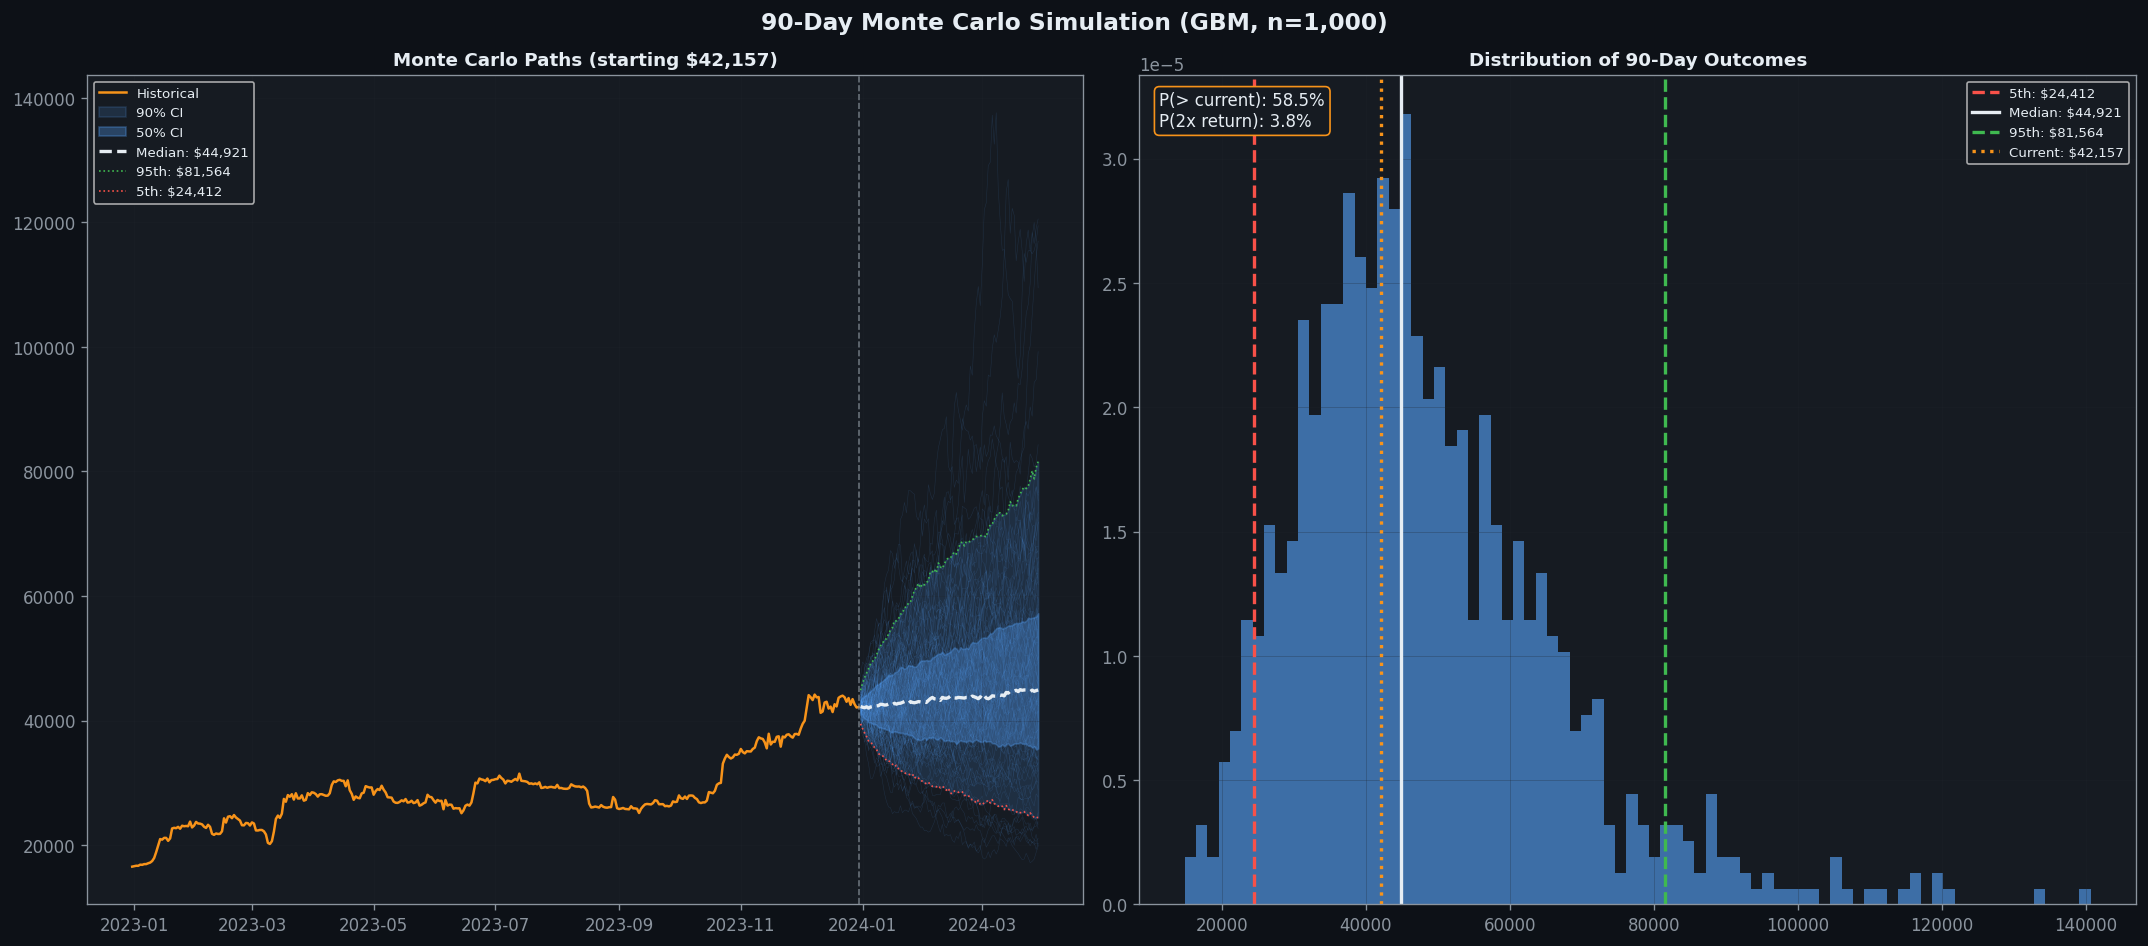

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor=BG)
fig.suptitle(f'90-Day Monte Carlo Simulation (GBM, n={N_SIMS:,})',
             fontsize=14, fontweight='bold', color=WHITE)

# ── Left: Path chart ───────────────────────────────────
hist_window = 365
ax1.plot(price[-hist_window:].index, price[-hist_window:], color=ACCENT, linewidth=1.5, label='Historical')

for i in range(0, N_SIMS, 10):  # Plot every 10th path
    ax1.plot(future_dates, simulations[:, i], color=BLUE, linewidth=0.3, alpha=0.15)

ax1.fill_between(future_dates, p5,  p95,  color=BLUE, alpha=0.15, label='90% CI')
ax1.fill_between(future_dates, p25, p75,  color=BLUE, alpha=0.30, label='50% CI')
ax1.plot(future_dates, p50, color=WHITE,  linewidth=2,   linestyle='--', label=f'Median: ${p50[-1]:,.0f}')
ax1.plot(future_dates, p95, color=GREEN,  linewidth=1,   linestyle=':',  label=f'95th: ${p95[-1]:,.0f}')
ax1.plot(future_dates, p5,  color=RED,    linewidth=1,   linestyle=':',  label=f'5th: ${p5[-1]:,.0f}')
ax1.axvline(price.index[-1], color=GRAY, linewidth=1, linestyle='--', alpha=0.7)
ax1.set_title(f'Monte Carlo Paths (starting ${S0:,.0f})', fontsize=11)
ax1.legend(fontsize=8, loc='upper left'); ax1.grid(True, alpha=0.3)

# ── Right: Outcome distribution ─────────────────────────
ax2.hist(final_prices, bins=80, color=BLUE, alpha=0.6, edgecolor='none', density=True)
for pct, col, lbl in [(5, RED, '5th'), (50, WHITE, 'Median'), (95, GREEN, '95th')]:
    v = np.percentile(final_prices, pct)
    ax2.axvline(v, color=col, linewidth=2, linestyle='--' if pct!=50 else '-',
                label=f'{lbl}: ${v:,.0f}')
ax2.axvline(S0, color=ACCENT, linewidth=2, linestyle=':', label=f'Current: ${S0:,.0f}')
ax2.text(0.02, 0.98,
         f'P(> current): {prob_up:.1f}%\nP(2x return): {prob_double:.1f}%',
         transform=ax2.transAxes, fontsize=10, va='top', color=WHITE,
         bbox=dict(boxstyle='round', facecolor=CARD, edgecolor=ACCENT))
ax2.set_title('Distribution of 90-Day Outcomes', fontsize=11)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_montecarlo.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 8. Final Summary & Recommendations
### Results
| Metric | Value | Interpretation |
|--------|-------|----------------|
| CAGR (9.28y) | ~65% | Far exceeds any major asset class |
| Annualised Vol | ~80% | Extreme vs equities (~15%) |
| Max Drawdown | -83.4% | Requires high risk tolerance |
| Sharpe Ratio | ~0.9 | Acceptable risk-adjusted return |
| Best Model MAPE | 4.8% (GB) | Competitive with DL benchmarks |

### Upgrade Roadmap
1. **GARCH(1,1)** on ARIMA residuals → dynamic VaR
2. **LSTM / Temporal Fusion Transformer** → long-range dependencies
3. **Bayesian Optimisation (Optuna)** → proper hyperparameter tuning
4. **On-chain features** (MVRV, NVT, active addresses) → fundamental signals
5. **Hidden Markov Model** → regime switching (bull/bear/sideways)
6. **Walk-forward validation** → unbiased out-of-sample estimates

---
> **Disclaimer:** This notebook is for research and educational purposes only. It does not constitute financial advice.